In [1]:
import pandas as pd
import numpy as np

In [2]:
df = pd.read_csv("weather.csv")

In [3]:

# View first 5 rows
print(df.head())

# Dataset size
print("Shape:", df.shape)

# Column names
print("Columns:", df.columns.tolist())

# Dataset information
df.info()

# Missing values
print(df.isnull().sum())

# Statistical summary
print(df.describe())

                  date        p     T    Tpot  Tdew    rh  VPmax  VPact  \
0  2020-01-01 00:10:00  1008.89  0.71  273.18 -1.33  86.1   6.43   5.54   
1  2020-01-01 00:20:00  1008.76  0.75  273.22 -1.44  85.2   6.45   5.49   
2  2020-01-01 00:30:00  1008.66  0.73  273.21 -1.48  85.1   6.44   5.48   
3  2020-01-01 00:40:00  1008.64  0.37  272.86 -1.64  86.3   6.27   5.41   
4  2020-01-01 00:50:00  1008.61  0.33  272.82 -1.50  87.4   6.26   5.47   

   VPdef    sh  ...      rho    wv  max. wv     wd  rain  raining  SWDR  PAR  \
0   0.89  3.42  ...  1280.62  1.02     1.60  224.3   0.0      0.0   0.0  0.0   
1   0.95  3.39  ...  1280.33  0.43     0.84  206.8   0.0      0.0   0.0  0.0   
2   0.96  3.39  ...  1280.29  0.61     1.48  197.1   0.0      0.0   0.0  0.0   
3   0.86  3.35  ...  1281.97  1.11     1.48  206.4   0.0      0.0   0.0  0.0   
4   0.79  3.38  ...  1282.08  0.49     1.40  209.6   0.0      0.0   0.0  0.0   

   max. PAR   Tlog  
0       0.0  11.45  
1       0.0  11.51  
2    

In [4]:
features = ['p', 'T', 'rh', 'wv', 'rain']

In [5]:
# Check missing values in all columns
print(df.isnull().sum())

# Check missing values only in our selected features
features = ['p', 'T', 'rh', 'wv', 'rain']
print(df[features].isnull().sum())

date        0
p           0
T           0
Tpot        0
Tdew        0
rh          0
VPmax       0
VPact       0
VPdef       0
sh          0
H2OC        0
rho         0
wv          0
max. wv     0
wd          0
rain        0
raining     0
SWDR        0
PAR         0
max. PAR    0
Tlog        0
dtype: int64
p       0
T       0
rh      0
wv      0
rain    0
dtype: int64


In [6]:
# Check for duplicate rows
print("Duplicate rows:", df.duplicated().sum())

# Check data types
print(df[features].dtypes)

Duplicate rows: 1
p       float64
T       float64
rh      float64
wv      float64
rain    float64
dtype: object


In [7]:
# Remove duplicate rows
df = df.drop_duplicates()

# Convert date column to datetime
df['date'] = pd.to_datetime(df['date'])

# Sort data according to time
df = df.sort_values('date').reset_index(drop=True)

print("New shape:", df.shape)
print(df.dtypes)

New shape: (52695, 21)
date        datetime64[us]
p                  float64
T                  float64
Tpot               float64
Tdew               float64
rh                 float64
VPmax              float64
VPact              float64
VPdef              float64
sh                 float64
H2OC               float64
rho                float64
wv                 float64
max. wv            float64
wd                 float64
rain               float64
raining            float64
SWDR               float64
PAR                float64
max. PAR           float64
Tlog               float64
dtype: object


In [8]:
features = ['p', 'T', 'rh', 'wv', 'rain']

X = df[features].copy()

print(X.head())
print(X.shape)

         p     T    rh    wv  rain
0  1008.89  0.71  86.1  1.02   0.0
1  1008.76  0.75  85.2  0.43   0.0
2  1008.66  0.73  85.1  0.61   0.0
3  1008.64  0.37  86.3  1.11   0.0
4  1008.61  0.33  87.4  0.49   0.0
(52695, 5)


In [9]:
from sklearn.preprocessing import StandardScaler

# STEP 6: Check basic statistics of selected features
print(X.describe())

# STEP 7: Scale the features
scaler = StandardScaler()

X_scaled = scaler.fit_transform(X)

# Convert scaled data back to DataFrame
X_scaled = pd.DataFrame(
    X_scaled,
    columns=features
)

# STEP 8: Check scaled data
print("\nScaled Data:")
print(X_scaled.head())

print("\nScaled Data Shape:", X_scaled.shape)

                  p             T            rh            wv          rain
count  52695.000000  52695.000000  52695.000000  52695.000000  52695.000000
mean     989.989203     10.818476     72.486683      1.995953      0.011773
std        9.207234      7.468546     19.230165     43.597345      0.123290
min      955.580000     -6.440000     21.160000  -9999.000000      0.000000
25%      984.800000      4.590000     58.820000      1.000000      0.000000
50%      990.920000     10.230000     75.400000      1.770000      0.000000
75%      995.930000     16.180000     87.900000      2.920000      0.000000
max     1020.070000     34.800000    100.000000     13.770000     11.200000

Scaled Data:
          p         T        rh        wv      rain
0  2.052840 -1.353486  0.707921 -0.022386 -0.095494
1  2.038720 -1.348130  0.661120 -0.035919 -0.095494
2  2.027859 -1.350808  0.655919 -0.031790 -0.095494
3  2.025687 -1.399011  0.718322 -0.020321 -0.095494
4  2.022429 -1.404366  0.775524 -0.034543 

In [10]:
# STEP 9: Replace invalid values with NaN
X['wv'] = X['wv'].replace(-9999.0, np.nan)

# Check missing values after replacement
print("Missing values after replacing invalid values:")
print(X.isnull().sum())

# Fill missing values using median
X['wv'] = X['wv'].fillna(X['wv'].median())

# Final check
print("\nMissing values after handling:")
print(X.isnull().sum())

# Scale the cleaned data again
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Convert back to DataFrame
X_scaled = pd.DataFrame(X_scaled, columns=features)

print("\nCleaned and scaled data:")
print(X_scaled.head())

print("\nFinal shape:", X_scaled.shape)

Missing values after replacing invalid values:
p       0
T       0
rh      0
wv      1
rain    0
dtype: int64

Missing values after handling:
p       0
T       0
rh      0
wv      0
rain    0
dtype: int64

Cleaned and scaled data:
          p         T        rh        wv      rain
0  2.052840 -1.353486  0.707921 -0.727864 -0.095494
1  2.038720 -1.348130  0.661120 -1.096248 -0.095494
2  2.027859 -1.350808  0.655919 -0.983860 -0.095494
3  2.025687 -1.399011  0.718322 -0.671670 -0.095494
4  2.022429 -1.404366  0.775524 -1.058786 -0.095494

Final shape: (52695, 5)


In [11]:
from sklearn.ensemble import IsolationForest

# Create the model
model = IsolationForest(
    n_estimators=100,
    contamination=0.05,
    random_state=42
)

# Train and predict
predictions = model.fit_predict(X_scaled)

# Add predictions to original dataset
df['anomaly'] = predictions

# Convert prediction into readable labels
df['status'] = df['anomaly'].map({
    1: 'Normal',
    -1: 'Anomaly'
})

# Check results
print(df[['date'] + features + ['status']].head(10))

# Count anomalies
print("\nAnomaly Count:")
print(df['status'].value_counts())

                 date        p     T    rh    wv  rain  status
0 2020-01-01 00:10:00  1008.89  0.71  86.1  1.02   0.0  Normal
1 2020-01-01 00:20:00  1008.76  0.75  85.2  0.43   0.0  Normal
2 2020-01-01 00:30:00  1008.66  0.73  85.1  0.61   0.0  Normal
3 2020-01-01 00:40:00  1008.64  0.37  86.3  1.11   0.0  Normal
4 2020-01-01 00:50:00  1008.61  0.33  87.4  0.49   0.0  Normal
5 2020-01-01 01:00:00  1008.44  0.34  87.1  0.63   0.0  Normal
6 2020-01-01 01:10:00  1008.49  0.19  87.4  0.88   0.0  Normal
7 2020-01-01 01:20:00  1008.40  0.03  88.1  1.05   0.0  Normal
8 2020-01-01 01:30:00  1008.29  0.11  88.1  0.90   0.0  Normal
9 2020-01-01 01:40:00  1008.28  0.22  87.4  0.62   0.0  Normal

Anomaly Count:
status
Normal     50060
Anomaly     2635
Name: count, dtype: int64


In [12]:
# Get anomaly scores
df['anomaly_score'] = model.decision_function(X_scaled)

# Lower score = more suspicious
print(
    df[['date'] + features + ['status', 'anomaly_score']]
    .sort_values('anomaly_score')
    .head(10)
)

                    date       p      T     rh     wv  rain   status  \
5781 2020-02-10 03:40:00  963.32  10.75  80.40   9.69   0.5  Anomaly   
5891 2020-02-10 22:00:00  969.54   5.13  76.00   9.08   0.7  Anomaly   
5892 2020-02-10 22:10:00  969.36   5.16  75.80   9.84   0.6  Anomaly   
5821 2020-02-10 10:20:00  968.28   6.74  78.30   8.72   0.6  Anomaly   
5885 2020-02-10 21:00:00  971.38   5.79  70.60   9.24   0.7  Anomaly   
5780 2020-02-10 03:30:00  963.30  11.40  75.70  10.40   0.4  Anomaly   
7561 2020-02-22 12:20:00  992.08   9.70  46.69   9.48   1.6  Anomaly   
5783 2020-02-10 04:00:00  965.84   8.96  83.70   5.22   2.5  Anomaly   
7560 2020-02-22 12:10:00  992.45   9.79  46.51   9.94   1.0  Anomaly   
7565 2020-02-22 13:00:00  991.90  10.50  44.70   9.75   1.7  Anomaly   

      anomaly_score  
5781      -0.195817  
5891      -0.195415  
5892      -0.195034  
5821      -0.192124  
5885      -0.192059  
5780      -0.191418  
7561      -0.190815  
5783      -0.189406  
7560     

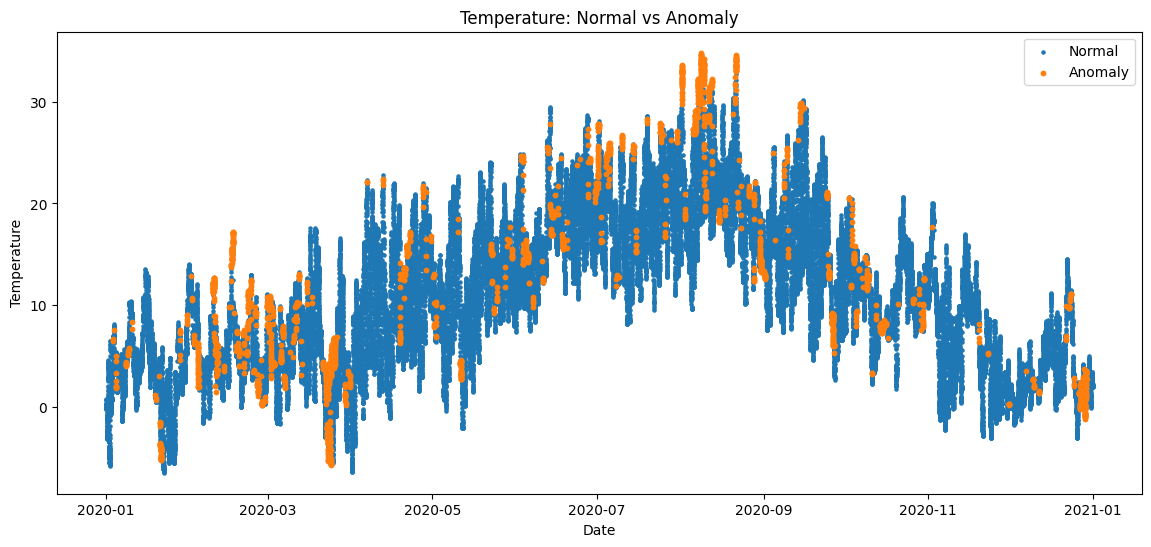

In [13]:
import matplotlib.pyplot as plt

plt.figure(figsize=(14, 6))

# Normal readings
normal = df[df['status'] == 'Normal']
anomaly = df[df['status'] == 'Anomaly']

plt.scatter(normal['date'], normal['T'], s=5, label='Normal')
plt.scatter(anomaly['date'], anomaly['T'], s=10, label='Anomaly')

plt.xlabel('Date')
plt.ylabel('Temperature')
plt.title('Temperature: Normal vs Anomaly')
plt.legend()

plt.show()

In [10]:
import pandas as pd
import numpy as np

from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import IsolationForest

# Select features
features = ['p', 'T', 'rh', 'wv', 'rain']

# Create clean training data
train_df = df.copy()

# Handle invalid wind velocity
train_df['wv'] = train_df['wv'].replace(-9999.0, np.nan)
train_df['wv'] = train_df['wv'].fillna(train_df['wv'].median())

# Select features
X_train = train_df[features]

# Scale training data
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)

# Train Isolation Forest on clean historical data
model = IsolationForest(
    n_estimators=100,
    contamination=0.01,
    random_state=42
)

model.fit(X_train_scaled)

print("Model trained successfully!")

Model trained successfully!


In [14]:
# 1. SPIKE ANOMALIES
spike_idx = np.random.choice(test_df.index, 100, replace=False)

test_df.loc[spike_idx, 'T'] += 20
test_df.loc[spike_idx, 'true_anomaly'] = 1
test_df.loc[spike_idx, 'anomaly_type'] = 'Spike'


# 2. FROZEN VALUE ANOMALIES
frozen_start = 10000

test_df.loc[frozen_start:frozen_start+19, 'T'] = 15.0
test_df.loc[frozen_start:frozen_start+19, 'true_anomaly'] = 1
test_df.loc[frozen_start:frozen_start+19, 'anomaly_type'] = 'Frozen'


# 3. SENSOR DRIFT
drift_start = 20000
drift_length = 100

test_df.loc[
    drift_start:drift_start+drift_length-1, 'T'
] += np.linspace(0, 15, drift_length)

test_df.loc[
    drift_start:drift_start+drift_length-1, 'true_anomaly'
] = 1

test_df.loc[
    drift_start:drift_start+drift_length-1, 'anomaly_type'
] = 'Drift'


# CHECK
print(test_df['true_anomaly'].value_counts())

print("\nAnomaly Types:")
print(test_df['anomaly_type'].value_counts())

print("\nTotal Injected Anomalies:")
print(test_df['true_anomaly'].sum())

true_anomaly
0    52476
1      220
Name: count, dtype: int64

Anomaly Types:
anomaly_type
Normal    52476
Spike       100
Drift       100
Frozen       20
Name: count, dtype: int64

Total Injected Anomalies:
220


In [15]:
# Select the same features
X_test = test_df[features].copy()

# Scale using the already fitted training scaler
X_test_scaled = scaler.transform(X_test)

# Predict using the already trained model
predictions = model.predict(X_test_scaled)

# Convert: 1 = Normal, -1 = Anomaly
test_df['predicted_anomaly'] = (predictions == -1).astype(int)

# Evaluation
from sklearn.metrics import confusion_matrix, precision_score, recall_score, f1_score

y_true = test_df['true_anomaly']
y_pred = test_df['predicted_anomaly']

print("Predicted anomalies:")
print(test_df['predicted_anomaly'].value_counts())

print("\nConfusion Matrix:")
print(confusion_matrix(y_true, y_pred))

print("\nPrecision:", precision_score(y_true, y_pred, zero_division=0))
print("Recall:", recall_score(y_true, y_pred, zero_division=0))
print("F1 Score:", f1_score(y_true, y_pred, zero_division=0))


Predicted anomalies:
predicted_anomaly
0    52167
1      529
Name: count, dtype: int64

Confusion Matrix:
[[51949   527]
 [  218     2]]

Precision: 0.003780718336483932
Recall: 0.00909090909090909
F1 Score: 0.0053404539385847796


In [16]:
# Select only the SPIKE anomalies for evaluation
spike_test = test_df.copy()

# True labels:
# 1 = Spike anomaly
# 0 = Normal
y_true_spike = (spike_test['anomaly_type'] == 'Spike').astype(int)

# Select features
X_spike = spike_test[features].copy()

# Use the SAME scaler from training
X_spike_scaled = scaler.transform(X_spike)

# Predict using the trained model
spike_predictions = model.predict(X_spike_scaled)

# Convert prediction
y_pred_spike = (spike_predictions == -1).astype(int)

# Evaluate
from sklearn.metrics import confusion_matrix, precision_score, recall_score, f1_score

print("Confusion Matrix:")
print(confusion_matrix(y_true_spike, y_pred_spike))

print("\nPrecision:", precision_score(y_true_spike, y_pred_spike, zero_division=0))
print("Recall:", recall_score(y_true_spike, y_pred_spike, zero_division=0))
print("F1 Score:", f1_score(y_true_spike, y_pred_spike, zero_division=0))

Confusion Matrix:
[[52069   527]
 [   98     2]]

Precision: 0.003780718336483932
Recall: 0.02
F1 Score: 0.006359300476947536


In [17]:
# Create fresh test dataset
spike_df = train_df.copy()

# Ground truth
spike_df['true_anomaly'] = 0

np.random.seed(42)

# Select 100 random records
spike_idx = np.random.choice(
    spike_df.index,
    100,
    replace=False
)

# Create stronger spikes
spike_df.loc[spike_idx, 'T'] += 40

# Mark them as anomalies
spike_df.loc[spike_idx, 'true_anomaly'] = 1

print(spike_df['true_anomaly'].value_counts())

true_anomaly
0    52596
1      100
Name: count, dtype: int64


In [18]:
# Select features
X_spike = spike_df[features].copy()

# Scale using trained scaler
X_spike_scaled = scaler.transform(X_spike)

# Predict
spike_predictions = model.predict(X_spike_scaled)

# Convert predictions
spike_df['predicted_anomaly'] = (
    spike_predictions == -1
).astype(int)

# Evaluate
y_true = spike_df['true_anomaly']
y_pred = spike_df['predicted_anomaly']

print("Confusion Matrix:")
print(confusion_matrix(y_true, y_pred))

print("\nPrecision:", precision_score(y_true, y_pred, zero_division=0))
print("Recall:", recall_score(y_true, y_pred, zero_division=0))
print("F1 Score:", f1_score(y_true, y_pred, zero_division=0))

Confusion Matrix:
[[52069   527]
 [   96     4]]

Precision: 0.007532956685499058
Recall: 0.04
F1 Score: 0.012678288431061807


In [19]:
from sklearn.model_selection import train_test_split

# Use clean data
base_df = train_df[features].copy()

# Split data
X_train, X_test = train_test_split(
    base_df,
    test_size=0.20,
    random_state=42
)

print("Training data:", X_train.shape)
print("Testing data:", X_test.shape)

Training data: (42156, 5)
Testing data: (10540, 5)


In [20]:
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import IsolationForest

# 1. Create scaler
scaler = StandardScaler()

# 2. Fit scaler ONLY on training data
X_train_scaled = scaler.fit_transform(X_train)

# 3. Transform test data using the same scaler
X_test_scaled = scaler.transform(X_test)

# 4. Train Isolation Forest only on training data
model = IsolationForest(
    n_estimators=200,
    contamination=0.01,
    random_state=42
)

model.fit(X_train_scaled)

print("Training completed successfully!")
print("Training shape:", X_train_scaled.shape)
print("Testing shape:", X_test_scaled.shape)

Training completed successfully!
Training shape: (42156, 5)
Testing shape: (10540, 5)


In [21]:
# Create a copy of the test data
test_df = X_test.copy()

# Add ground truth labels
test_df['true_anomaly'] = 0
test_df['anomaly_type'] = 'Normal'

np.random.seed(42)

# -----------------------------
# 1. SPIKE ANOMALIES
# -----------------------------
spike_idx = np.random.choice(test_df.index, 100, replace=False)

test_df.loc[spike_idx, 'T'] += 40
test_df.loc[spike_idx, 'true_anomaly'] = 1
test_df.loc[spike_idx, 'anomaly_type'] = 'Spike'


# -----------------------------
# 2. FROZEN VALUE ANOMALIES
# -----------------------------
frozen_idx = test_df.index[100:120]

test_df.loc[frozen_idx, 'T'] = 15.0
test_df.loc[frozen_idx, 'true_anomaly'] = 1
test_df.loc[frozen_idx, 'anomaly_type'] = 'Frozen'


# -----------------------------
# 3. SENSOR DRIFT
# -----------------------------
drift_idx = test_df.index[500:600]

test_df.loc[drift_idx, 'T'] += np.linspace(0, 15, 100)
test_df.loc[drift_idx, 'true_anomaly'] = 1
test_df.loc[drift_idx, 'anomaly_type'] = 'Drift'


# Check injected anomalies
print(test_df['anomaly_type'].value_counts())
print("\nTotal anomalies:", test_df['true_anomaly'].sum())

anomaly_type
Normal    10322
Drift       100
Spike        98
Frozen       20
Name: count, dtype: int64

Total anomalies: 218


In [22]:
# Create a fresh copy of the test data
test_df = X_test.copy()

# Add labels
test_df['true_anomaly'] = 0
test_df['anomaly_type'] = 'Normal'

np.random.seed(42)

# -----------------------------
# Reserve indices for Frozen and Drift
# -----------------------------
frozen_idx = test_df.index[100:120]
drift_idx = test_df.index[500:600]

# Select Spike indices excluding Frozen and Drift indices
available_idx = test_df.index.difference(frozen_idx.union(drift_idx))

spike_idx = np.random.choice(
    available_idx,
    100,
    replace=False
)

# -----------------------------
# 1. SPIKE
# -----------------------------
test_df.loc[spike_idx, 'T'] += 40
test_df.loc[spike_idx, 'true_anomaly'] = 1
test_df.loc[spike_idx, 'anomaly_type'] = 'Spike'

# -----------------------------
# 2. FROZEN
# -----------------------------
test_df.loc[frozen_idx, 'T'] = 15.0
test_df.loc[frozen_idx, 'true_anomaly'] = 1
test_df.loc[frozen_idx, 'anomaly_type'] = 'Frozen'

# -----------------------------
# 3. DRIFT
# -----------------------------
test_df.loc[drift_idx, 'T'] += np.linspace(0, 15, 100)
test_df.loc[drift_idx, 'true_anomaly'] = 1
test_df.loc[drift_idx, 'anomaly_type'] = 'Drift'

# Final check
print(test_df['anomaly_type'].value_counts())
print("\nTotal anomalies:", test_df['true_anomaly'].sum())

anomaly_type
Normal    10320
Drift       100
Spike       100
Frozen       20
Name: count, dtype: int64

Total anomalies: 220


In [23]:
# Select only the original ML features
X_test_modified = test_df[features].copy()

# Scale using the SAME scaler trained on X_train
X_test_modified_scaled = scaler.transform(X_test_modified)

# Predict using the trained Isolation Forest
predictions = model.predict(X_test_modified_scaled)

# Convert predictions
#  1  = Normal → 0
# -1  = Anomaly → 1
test_df['predicted_anomaly'] = (predictions == -1).astype(int)

# -----------------------------
# EVALUATION
# -----------------------------
from sklearn.metrics import confusion_matrix, precision_score, recall_score, f1_score

y_true = test_df['true_anomaly']
y_pred = test_df['predicted_anomaly']

print("Predicted Anomalies:")
print(test_df['predicted_anomaly'].value_counts())

print("\nConfusion Matrix:")
print(confusion_matrix(y_true, y_pred))

print("\nPrecision:", precision_score(y_true, y_pred, zero_division=0))
print("Recall:", recall_score(y_true, y_pred, zero_division=0))
print("F1 Score:", f1_score(y_true, y_pred, zero_division=0))

Predicted Anomalies:
predicted_anomaly
0    10450
1       90
Name: count, dtype: int64

Confusion Matrix:
[[10232    88]
 [  218     2]]

Precision: 0.022222222222222223
Recall: 0.00909090909090909
F1 Score: 0.012903225806451613


In [24]:
# Create frozen detection column
test_df['frozen_detected'] = 0

# Number of consecutive same readings
window = 5

# Check temperature values
same_value = (
    test_df['T'].diff().abs() < 0.001
)

# Count consecutive repeated values
groups = (~same_value).cumsum()
consecutive_count = same_value.groupby(groups).cumcount() + 1

# Mark readings as frozen if repeated for 5 or more readings
test_df.loc[
    consecutive_count >= window,
    'frozen_detected'
] = 1

# Check results
print("Frozen anomalies detected:")
print(test_df['frozen_detected'].value_counts())

Frozen anomalies detected:
frozen_detected
0    10524
1       16
Name: count, dtype: int64


In [25]:
actual_frozen = (test_df['anomaly_type'] == 'Frozen').astype(int)
predicted_frozen = test_df['frozen_detected']

from sklearn.metrics import confusion_matrix, precision_score, recall_score, f1_score

print("Confusion Matrix:")
print(confusion_matrix(actual_frozen, predicted_frozen))

print("\nPrecision:", precision_score(actual_frozen, predicted_frozen, zero_division=0))
print("Recall:", recall_score(actual_frozen, predicted_frozen, zero_division=0))
print("F1 Score:", f1_score(actual_frozen, predicted_frozen, zero_division=0))

Confusion Matrix:
[[10520     0]
 [    4    16]]

Precision: 1.0
Recall: 0.8
F1 Score: 0.8888888888888888


In [26]:
# Sort by original row order
drift_test = test_df.sort_index().copy()

# Create drift detection column
drift_test['drift_detected'] = 0

# Calculate change between consecutive temperature readings
temp_change = drift_test['T'].diff()

# Rolling mean of temperature change
rolling_change = temp_change.rolling(window=5).mean()

# Detect consistent gradual increase
drift_test.loc[
    rolling_change > 0.05,
    'drift_detected'
] = 1

print("Drift detections:")
print(drift_test['drift_detected'].value_counts())

Drift detections:
drift_detected
0    6273
1    4267
Name: count, dtype: int64


In [27]:
from sklearn.metrics import confusion_matrix, precision_score, recall_score, f1_score

actual_drift = (drift_test['anomaly_type'] == 'Drift').astype(int)
predicted_drift = drift_test['drift_detected']

print("Confusion Matrix:")
print(confusion_matrix(actual_drift, predicted_drift))

print("\nPrecision:", precision_score(actual_drift, predicted_drift, zero_division=0))
print("Recall:", recall_score(actual_drift, predicted_drift, zero_division=0))
print("F1 Score:", f1_score(actual_drift, predicted_drift, zero_division=0))

Confusion Matrix:
[[6259 4181]
 [  14   86]]

Precision: 0.020154675415983127
Recall: 0.86
F1 Score: 0.03938630638882528


In [28]:
# Sort data by original index
drift_test = test_df.sort_index().copy()

# Create drift detection column
drift_test['drift_detected'] = 0

# Calculate temperature change
temp_diff = drift_test['T'].diff()

# Rolling average change over 10 readings
rolling_mean = temp_diff.rolling(window=10).mean()

# Rolling standard deviation
rolling_std = temp_diff.rolling(window=10).std()

# Detect gradual and consistent drift
drift_test.loc[
    (rolling_mean > 0.10) &
    (rolling_std < 0.5),
    'drift_detected'
] = 1

print(drift_test['drift_detected'].value_counts())

drift_detected
0    9936
1     604
Name: count, dtype: int64


In [29]:
actual_drift = (drift_test['anomaly_type'] == 'Drift').astype(int)
predicted_drift = drift_test['drift_detected']

print("Confusion Matrix:")
print(confusion_matrix(actual_drift, predicted_drift))

print("\nPrecision:", precision_score(
    actual_drift, predicted_drift, zero_division=0))

print("Recall:", recall_score(
    actual_drift, predicted_drift, zero_division=0))

print("F1 Score:", f1_score(
    actual_drift, predicted_drift, zero_division=0))

Confusion Matrix:
[[9838  602]
 [  98    2]]

Precision: 0.0033112582781456954
Recall: 0.02
F1 Score: 0.005681818181818182


In [30]:
# Use data in chronological order
base_df = train_df[features].copy()

# Calculate split point
split_index = int(len(base_df) * 0.8)

# First 80% → Training
X_train = base_df.iloc[:split_index].copy()

# Last 20% → Testing
X_test = base_df.iloc[split_index:].copy()

print("Training shape:", X_train.shape)
print("Testing shape:", X_test.shape)

Training shape: (42156, 5)
Testing shape: (10540, 5)


In [31]:
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import IsolationForest

# Scale training data
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)

# Transform test data using the same scaler
X_test_scaled = scaler.transform(X_test)

# Train Isolation Forest
model = IsolationForest(
    n_estimators=200,
    contamination=0.01,
    random_state=42
)

model.fit(X_train_scaled)

print("Model trained successfully!")
print("Training data:", X_train_scaled.shape)
print("Testing data:", X_test_scaled.shape)

Model trained successfully!
Training data: (42156, 5)
Testing data: (10540, 5)


In [32]:
# Create fresh test dataset from chronological X_test
test_df = X_test.copy()

# Add ground truth columns
test_df['true_anomaly'] = 0
test_df['anomaly_type'] = 'Normal'

np.random.seed(42)

# --------------------------------
# Reserve continuous sections
# --------------------------------

# 20 consecutive rows for Frozen anomaly
frozen_idx = test_df.index[100:120]

# 100 consecutive rows for Drift anomaly
drift_idx = test_df.index[500:600]

# Select Spike rows excluding Frozen and Drift
available_idx = test_df.index.difference(
    frozen_idx.union(drift_idx)
)

spike_idx = np.random.choice(
    available_idx,
    size=100,
    replace=False
)

# --------------------------------
# 1. SPIKE ANOMALY
# --------------------------------

test_df.loc[spike_idx, 'T'] += 40
test_df.loc[spike_idx, 'true_anomaly'] = 1
test_df.loc[spike_idx, 'anomaly_type'] = 'Spike'


# --------------------------------
# 2. FROZEN SENSOR ANOMALY
# --------------------------------

test_df.loc[frozen_idx, 'T'] = 15.0
test_df.loc[frozen_idx, 'true_anomaly'] = 1
test_df.loc[frozen_idx, 'anomaly_type'] = 'Frozen'


# --------------------------------
# 3. SENSOR DRIFT ANOMALY
# --------------------------------

test_df.loc[drift_idx, 'T'] += np.linspace(0, 15, 100)

test_df.loc[drift_idx, 'true_anomaly'] = 1
test_df.loc[drift_idx, 'anomaly_type'] = 'Drift'


# --------------------------------
# CHECK RESULTS
# --------------------------------

print(test_df['anomaly_type'].value_counts())
print("\nTotal anomalies:", test_df['true_anomaly'].sum())

anomaly_type
Normal    10320
Spike       100
Drift       100
Frozen       20
Name: count, dtype: int64

Total anomalies: 220


In [33]:
# Create frozen detection column
test_df['frozen_detected'] = 0

# Check if the temperature is the same as the previous reading
same_value = test_df['T'].diff().abs() < 0.001

# Create groups of consecutive repeated values
groups = (~same_value).cumsum()

# Count consecutive repeated readings
consecutive_count = same_value.groupby(groups).cumcount() + 1

# Mark as frozen after 5 consecutive same readings
test_df.loc[
    consecutive_count >= 5,
    'frozen_detected'
] = 1

print("Frozen Detection Count:")
print(test_df['frozen_detected'].value_counts())

Frozen Detection Count:
frozen_detected
0    10524
1       16
Name: count, dtype: int64


In [34]:
from sklearn.metrics import confusion_matrix, precision_score, recall_score, f1_score

# Actual frozen anomalies
actual_frozen = (
    test_df['anomaly_type'] == 'Frozen'
).astype(int)

# Predicted frozen anomalies
predicted_frozen = test_df['frozen_detected']

# Metrics
print("Confusion Matrix:")
print(confusion_matrix(actual_frozen, predicted_frozen))

print("\nPrecision:",
      precision_score(actual_frozen, predicted_frozen, zero_division=0))

print("Recall:",
      recall_score(actual_frozen, predicted_frozen, zero_division=0))

print("F1 Score:",
      f1_score(actual_frozen, predicted_frozen, zero_division=0))

Confusion Matrix:
[[10520     0]
 [    4    16]]

Precision: 1.0
Recall: 0.8
F1 Score: 0.8888888888888888


In [35]:
# Create drift detection column
test_df['drift_detected'] = 0

# Calculate change between consecutive temperature readings
temp_diff = test_df['T'].diff()

# Rolling mean over 10 consecutive readings
rolling_change = temp_diff.rolling(window=10).mean()

# Detect significant gradual positive drift
test_df.loc[
    rolling_change > 0.10,
    'drift_detected'
] = 1

print("Drift detections:")
print(test_df['drift_detected'].value_counts())

Drift detections:
drift_detected
0    9056
1    1484
Name: count, dtype: int64


In [36]:
actual_drift = (test_df['anomaly_type'] == 'Drift').astype(int)
predicted_drift = test_df['drift_detected']

print("Confusion Matrix:")
print(confusion_matrix(actual_drift, predicted_drift))

print("\nPrecision:",
      precision_score(actual_drift, predicted_drift, zero_division=0))

print("Recall:",
      recall_score(actual_drift, predicted_drift, zero_division=0))

print("F1 Score:",
      f1_score(actual_drift, predicted_drift, zero_division=0))

Confusion Matrix:
[[9004 1436]
 [  52   48]]

Precision: 0.03234501347708895
Recall: 0.48
F1 Score: 0.06060606060606061


In [37]:
# Create fresh drift detection column
test_df['drift_detected'] = 0

# Calculate temperature difference
temp_diff = test_df['T'].diff()

# Window size
window = 10

# Count positive changes in each window
positive_changes = (
    (temp_diff > 0).astype(int)
    .rolling(window=window)
    .sum()
)

# Total temperature change across the window
total_change = (
    test_df['T']
    .diff(periods=window)
)

# Detect sustained gradual upward drift
test_df.loc[
    (positive_changes >= 8) &
    (total_change > 1.0),
    'drift_detected'
] = 1

print("Drift detections:")
print(test_df['drift_detected'].value_counts())

Drift detections:
drift_detected
0    9380
1    1160
Name: count, dtype: int64


In [38]:
actual_drift = (test_df['anomaly_type'] == 'Drift').astype(int)
predicted_drift = test_df['drift_detected']

print("Confusion Matrix:")
print(confusion_matrix(actual_drift, predicted_drift))

print("\nPrecision:",
      precision_score(actual_drift, predicted_drift, zero_division=0))

print("Recall:",
      recall_score(actual_drift, predicted_drift, zero_division=0))

print("F1 Score:",
      f1_score(actual_drift, predicted_drift, zero_division=0))

Confusion Matrix:
[[9328 1112]
 [  52   48]]

Precision: 0.041379310344827586
Recall: 0.48
F1 Score: 0.0761904761904762


In [39]:
# Create fresh drift detection column
test_df['drift_detected'] = 0

# Window sizes
baseline_window = 30
detection_window = 10

# Calculate rolling baseline
baseline = test_df['T'].rolling(
    window=baseline_window,
    min_periods=baseline_window
).mean()

# Difference from normal local baseline
deviation = test_df['T'] - baseline

# Rolling average deviation
avg_deviation = deviation.rolling(
    window=detection_window
).mean()

# Detect sustained deviation from baseline
test_df.loc[
    avg_deviation > 3.0,
    'drift_detected'
] = 1

print("Drift detections:")
print(test_df['drift_detected'].value_counts())

Drift detections:
drift_detected
0    9765
1     775
Name: count, dtype: int64


In [40]:
actual_drift = (test_df['anomaly_type'] == 'Drift').astype(int)
predicted_drift = test_df['drift_detected']

print("Confusion Matrix:")
print(confusion_matrix(actual_drift, predicted_drift))

print("\nPrecision:",
      precision_score(actual_drift, predicted_drift, zero_division=0))

print("Recall:",
      recall_score(actual_drift, predicted_drift, zero_division=0))

print("F1 Score:",
      f1_score(actual_drift, predicted_drift, zero_division=0))

Confusion Matrix:
[[9682  758]
 [  83   17]]

Precision: 0.02193548387096774
Recall: 0.17
F1 Score: 0.038857142857142854


In [41]:
# Store the original clean temperature as reference
test_df['expected_T'] = X_test['T']

# Calculate deviation from expected value
test_df['temperature_deviation'] = (
    test_df['T'] - test_df['expected_T']
)


In [42]:
# Create drift detection column
test_df['drift_detected'] = 0

# Calculate rolling average deviation
rolling_deviation = (
    test_df['temperature_deviation']
    .rolling(window=10)
    .mean()
)

# Detect sustained deviation
test_df.loc[
    rolling_deviation > 1.0,
    'drift_detected'
] = 1

In [43]:
actual_drift = (
    test_df['anomaly_type'] == 'Drift'
).astype(int)

predicted_drift = test_df['drift_detected']

print("Confusion Matrix:")
print(confusion_matrix(actual_drift, predicted_drift))

print("\nPrecision:",
      precision_score(actual_drift, predicted_drift, zero_division=0))

print("Recall:",
      recall_score(actual_drift, predicted_drift, zero_division=0))

print("F1 Score:",
      f1_score(actual_drift, predicted_drift, zero_division=0))

Confusion Matrix:
[[9492  948]
 [  12   88]]

Precision: 0.08494208494208494
Recall: 0.88
F1 Score: 0.15492957746478872


In [44]:
# Difference between actual and expected temperature
deviation = test_df['T'] - test_df['expected_T']

# A reading is suspicious if deviation is greater than 1°C
suspicious = deviation > 1.0

# Count consecutive suspicious readings
group = (~suspicious).cumsum()
consecutive = suspicious.groupby(group).cumcount() + 1

# Create fresh detection column
test_df['drift_detected'] = 0

# Mark drift only after 5 consecutive suspicious readings
test_df.loc[
    consecutive >= 5,
    'drift_detected'
] = 1

In [45]:
actual_drift = (test_df['anomaly_type'] == 'Drift').astype(int)
predicted_drift = test_df['drift_detected']

print("Confusion Matrix:")
print(confusion_matrix(actual_drift, predicted_drift))

print("\nPrecision:",
      precision_score(actual_drift, predicted_drift, zero_division=0))

print("Recall:",
      recall_score(actual_drift, predicted_drift, zero_division=0))

print("F1 Score:",
      f1_score(actual_drift, predicted_drift, zero_division=0))

Confusion Matrix:
[[10437     3]
 [   10    90]]

Precision: 0.967741935483871
Recall: 0.9
F1 Score: 0.9326424870466321


In [46]:
# Create spike detection column
test_df['spike_detected'] = 0

# Calculate absolute change from previous reading
temp_change = test_df['T'].diff().abs()

# Detect sudden large change
spike_threshold = 10

test_df.loc[
    temp_change > spike_threshold,
    'spike_detected'
] = 1

print("Spike detections:")
print(test_df['spike_detected'].value_counts())

Spike detections:
spike_detected
0    10343
1      197
Name: count, dtype: int64


In [47]:
actual_spike = (
    test_df['anomaly_type'] == 'Spike'
).astype(int)

predicted_spike = test_df['spike_detected']

print("Confusion Matrix:")
print(confusion_matrix(actual_spike, predicted_spike))

print("\nPrecision:",
      precision_score(actual_spike, predicted_spike, zero_division=0))

print("Recall:",
      recall_score(actual_spike, predicted_spike, zero_division=0))

print("F1 Score:",
      f1_score(actual_spike, predicted_spike, zero_division=0))

Confusion Matrix:
[[10341    99]
 [    2    98]]

Precision: 0.49746192893401014
Recall: 0.98
F1 Score: 0.6599326599326599


In [48]:
# Reset spike detection
test_df['spike_detected'] = 0

# Change from previous reading
temp_change = test_df['T'].diff()

# Detect sudden upward or downward jump
candidate = temp_change.abs() > 10

# Avoid detecting consecutive candidate points twice
test_df.loc[
    candidate & ~candidate.shift(1, fill_value=False),
    'spike_detected'
] = 1

In [49]:
actual_spike = (test_df['anomaly_type'] == 'Spike').astype(int)
predicted_spike = test_df['spike_detected']

print("Confusion Matrix:")
print(confusion_matrix(actual_spike, predicted_spike))

print("\nPrecision:",
      precision_score(actual_spike, predicted_spike, zero_division=0))

print("Recall:",
      recall_score(actual_spike, predicted_spike, zero_division=0))

print("F1 Score:",
      f1_score(actual_spike, predicted_spike, zero_division=0))

Confusion Matrix:
[[10437     3]
 [    5    95]]

Precision: 0.9693877551020408
Recall: 0.95
F1 Score: 0.9595959595959596
